In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_mod = pd.read_csv('../df_mod.csv')
df_mod.head()

,merchant,category,amt,gender,street,city,state,zip,city_pop,job,...,last,lat,long,time,cc_num,trans_date_trans_time,trans_num,merch_lat,merch_long,dob
0,fraud_Kirlin and Sons,personal_care,2.86,M,351 Darlene Green,Columbia,SC,29209,333497,Mechanical engineer,...,Elliott,33.9659,-80.9355,1900-01-01 12:14:25,2291163933867244,2020-06-21 12:14:25,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,1968-03-19
1,fraud_Sporer-Keebler,personal_care,29.84,F,3638 Marsh Union,Altonah,UT,84002,302,"Sales professional, IT",...,Williams,40.3207,-110.4360,1900-01-01 12:14:33,3573030041201292,2020-06-21 12:14:33,324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,1990-01-17
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,9333 Valentine Point,Bellmore,NY,11710,34496,"Librarian, public",...,Lopez,40.6729,-73.5365,1900-01-01 12:14:53,3598215285024754,2020-06-21 12:14:53,c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,1970-10-21
3,fraud_Haley Group,misc_pos,60.05,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,54767,Set designer,...,Williams,28.5697,-80.8191,1900-01-01 12:15:15,3591919803438423,2020-06-21 12:15:15,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,1987-07-25
4,fraud_Johnston-Casper,travel,3.19,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,1126,Furniture designer,...,Massey,44.2529,-85.0170,1900-01-01 12:15:17,3526826139003047,2020-06-21 12:15:17,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,1955-07-06


In [3]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'job', 'first', 'last', 'lat', 'long', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num', 'merch_lat', 'merch_long', 'dob','year'
]

# Create a new DataFrame by dropping the specified columns
df_n = df_mod.drop(columns=columns_to_drop)

In [40]:
df_n.sample()

,amt,zip,city_pop,unix_time,is_fraud,month,day,age,dist_client_merch,mca_category,te_job,le_gender,te_street,te_merchant,te_city,te_state
147319,18.78,46765,5341,1376223943,0,8,11,29,99.276934,-0.064082,0.0,1,0.0,0.001149,0.0,0.00588


In [4]:
X = df_n.drop(columns=['is_fraud'])  # Features
y = df_n['is_fraud'] 

In [38]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


In [36]:
# from sklearn import metrics
# import matplotlib.pyplot as plt
# import numpy as np

# # Define a function to measure various metrics
# def measure_metrics(y_test, y_pred, y_prob=None):
#     # Print accuracy score
#     print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
#     # Plot confusion matrix with labels
#     cm = metrics.confusion_matrix(y_test, y_pred)
#     disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
#     disp.plot()
    
#     # Annotate the confusion matrix with TP, FP, FN, TN
#     plt.title('Confusion Matrix')
#     plt.xlabel('Predicted label')
#     plt.ylabel('True label')
#     ax = plt.gca()
#     ax.text(-0.3, 0.5, 'True Positives (TP)', va='center', ha='center', fontsize=12, color='green', transform=ax.transAxes)
#     ax.text(-0.3, 1.5, 'False Negatives (FN)', va='center', ha='center', fontsize=12, color='red', transform=ax.transAxes)
#     ax.text(0.5, -0.2, 'False Positives (FP)', va='center', ha='center', fontsize=12, color='red', transform=ax.transAxes)
#     ax.text(1.5, -0.2, 'True Negatives (TN)', va='center', ha='center', fontsize=12, color='green', transform=ax.transAxes)
#     plt.show()
    
#     # Print classification report
#     print(metrics.classification_report(y_test, y_pred))
    
#     if y_prob is not None:
#         # Calculate ROC AUC score
#         roc_auc = metrics.roc_auc_score(y_test, y_prob)
#         print("ROC AUC Score:", roc_auc)
        
#         # Plot ROC curve
#         fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
#         plt.figure()
#         plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
#         plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#         plt.xlim([0.0, 1.0])
#         plt.ylim([0.0, 1.05])
#         plt.xlabel('False Positive Rate')
#         plt.ylabel('True Positive Rate')
#         plt.title('Receiver Operating Characteristic')
#         plt.legend(loc="lower right")
#         plt.show()
#     else:
#         print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# # Example usage
# # Assuming y_test, y_pred, and y_prob are defined
# # measure_metrics(y_test, y_pred, y_prob)


# Balance Dataset using SMOTETomek

In [6]:
from imblearn.combine import SMOTETomek

# Instantiate SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)

# Resample the dataset
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Optionally, you can create a new balanced DataFrame if needed
balanced_df_n = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), 
                           pd.DataFrame(y_resampled, columns=['is_fraud'])], axis=1)


In [7]:
balanced_df_n['is_fraud'].value_counts()

is_fraud
0    553176
1    553176
Name: count, dtype: int64

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


In [9]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

In [10]:
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=40)



In [11]:
# svm.fit(X_train_balanced, y_train_balanced)


In [12]:
# y_pred_svm_balanced = svm.predict(X_test_balanced)


In [13]:
# y_prob_svm_balanced = svm.predict_proba(X_test_balanced)[:, 1]

### Decision Tree

In [16]:
dt.fit(X_train_balanced, y_train_balanced)
y_pred_dt_balanced = dt.predict(X_test_balanced)
y_prob_dt_balanced = dt.predict_proba(X_test_balanced)[:, 1]

Decision Tree Result
Accuracy: 0.9943191832639614
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    110857
           1       0.99      1.00      0.99    110414

    accuracy                           0.99    221271
   macro avg       0.99      0.99      0.99    221271
weighted avg       0.99      0.99      0.99    221271

ROC AUC Score: 0.9943245983901008


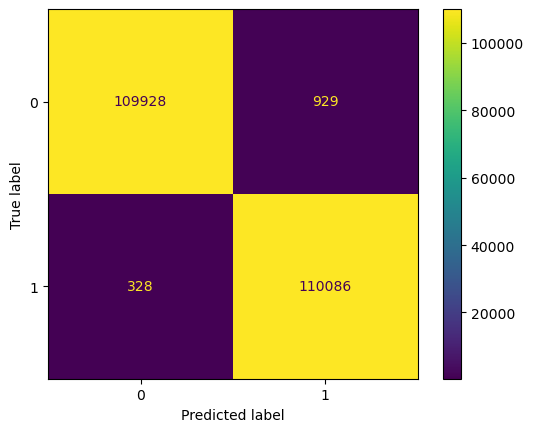

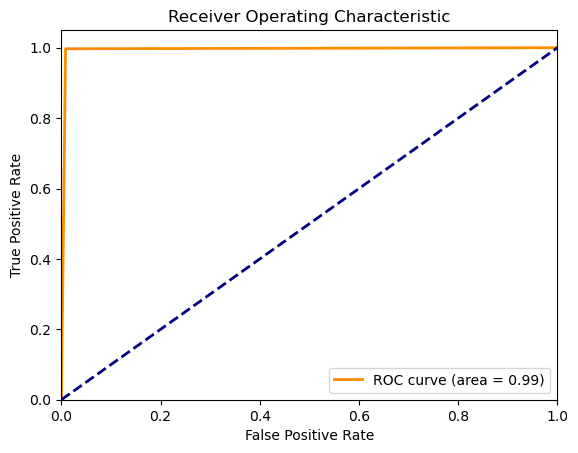

In [39]:
print('Decision Tree Result')
measure_metrics(y_test_balanced, y_pred_dt_balanced, y_prob_dt_balanced)

### Random Forest

In [19]:
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf_balanced = rf.predict(X_test_balanced)
y_prob_rf_balanced = dt.predict_proba(X_test_balanced)[:, 1]

Random Forest Result
Accuracy: 0.9984543839906721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110857
           1       1.00      1.00      1.00    110414

    accuracy                           1.00    221271
   macro avg       1.00      1.00      1.00    221271
weighted avg       1.00      1.00      1.00    221271

ROC AUC Score: 0.9943245983901008


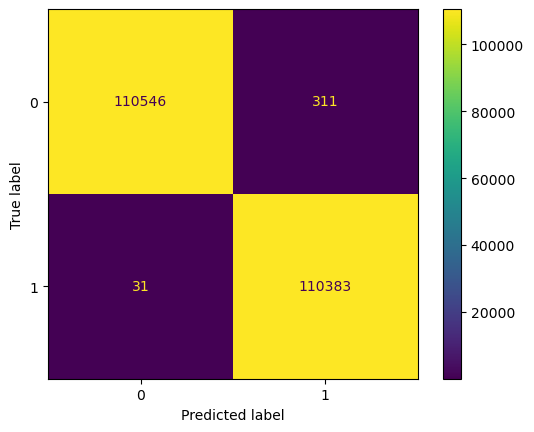

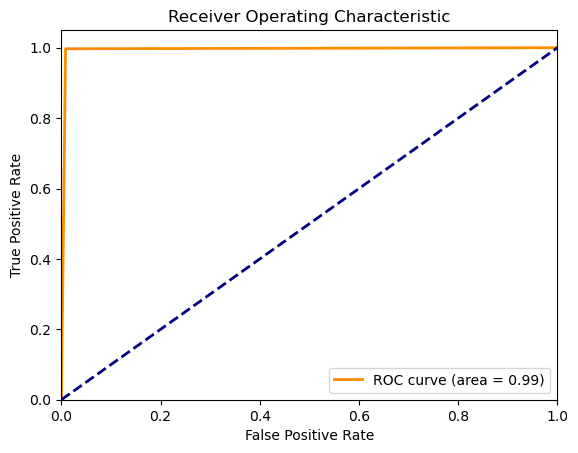

In [20]:
print('Random Forest Result')
measure_metrics(y_test_balanced, y_pred_rf_balanced, y_prob_rf_balanced)

### Logistic Regression

In [23]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr_balanced = lr.predict(X_test_balanced)
y_prob_lr_balanced = dt.predict_proba(X_test_balanced)[:, 1]

Logistic Regression Result
Accuracy: 0.8794961834130998
              precision    recall  f1-score   support

           0       0.83      0.95      0.89    110857
           1       0.95      0.80      0.87    110414

    accuracy                           0.88    221271
   macro avg       0.89      0.88      0.88    221271
weighted avg       0.89      0.88      0.88    221271

ROC AUC Score: 0.9943245983901008


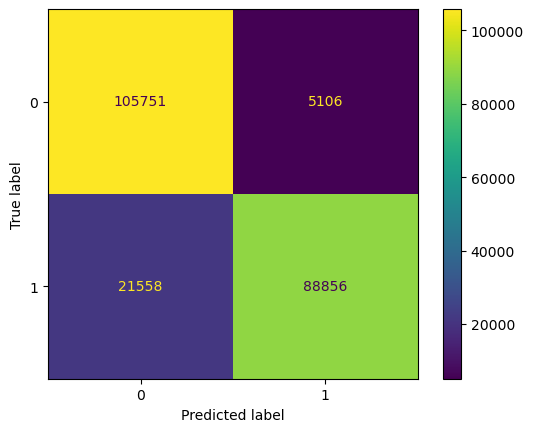

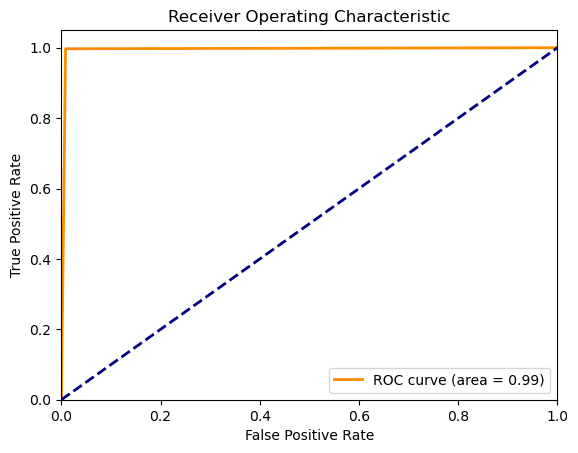

In [24]:
print('Logistic Regression Result')
measure_metrics(y_test_balanced, y_pred_lr_balanced, y_prob_lr_balanced)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

# Balance Dataset using SMOTE

In [25]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Resample the dataset
X_resampled_smote, y_resampled_smote = smote.fit_resample(X, y)

# Optionally, you can create a new balanced DataFrame if needed
balanced_df_smote = pd.concat([pd.DataFrame(X_resampled_smote, columns=X.columns), 
                               pd.DataFrame(y_resampled_smote, columns=['is_fraud'])], axis=1)


In [26]:
balanced_df_smote['is_fraud'].value_counts()

is_fraud
0    553574
1    553574
Name: count, dtype: int64

In [27]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_resampled_smote, y_resampled_smote, test_size=0.2, random_state=40)


In [11]:
# svm.fit(X_train_balanced, y_train_balanced)


In [12]:
# y_pred_svm_balanced = svm.predict(X_test_balanced)


In [13]:
# y_prob_svm_balanced = svm.predict_proba(X_test_balanced)[:, 1]

### Decision Tree

In [28]:
dt.fit(X_train_smote, y_train_smote)
y_pred_dt_smote = dt.predict(X_test_smote)
y_prob_dt_smote = dt.predict_proba(X_test_smote)[:, 1]

Decision Tree Result
Accuracy: 0.994603260624125
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    110899
           1       0.99      1.00      0.99    110531

    accuracy                           0.99    221430
   macro avg       0.99      0.99      0.99    221430
weighted avg       0.99      0.99      0.99    221430

ROC AUC Score: 0.9946076814327562


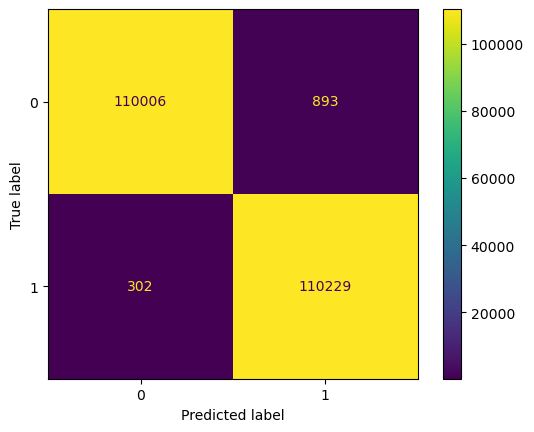

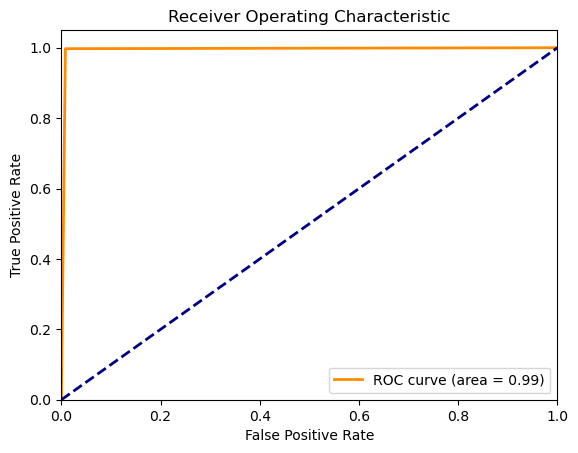

In [29]:
print('Decision Tree Result')
measure_metrics(y_test_smote, y_pred_dt_smote, y_prob_dt_smote)

### Random Forest

In [31]:
rf.fit(X_train_smote, y_train_smote)


In [63]:
y_pred_rd_smote = rf.predict(X)
y_prob_rd_smote = rf.predict_proba(X)[:, 1]

Decision Tree Result
Accuracy: 0.9993971773504235
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.99      0.93      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.99      0.96    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9999383215437437


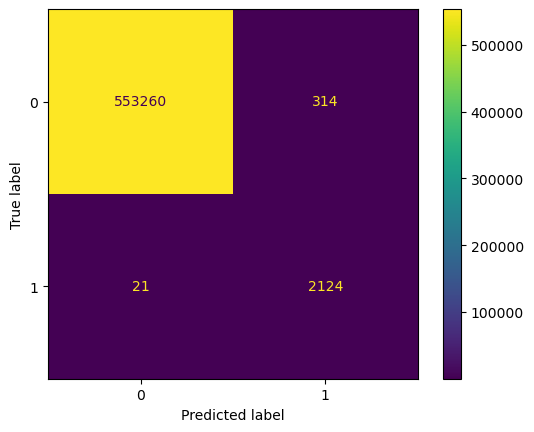

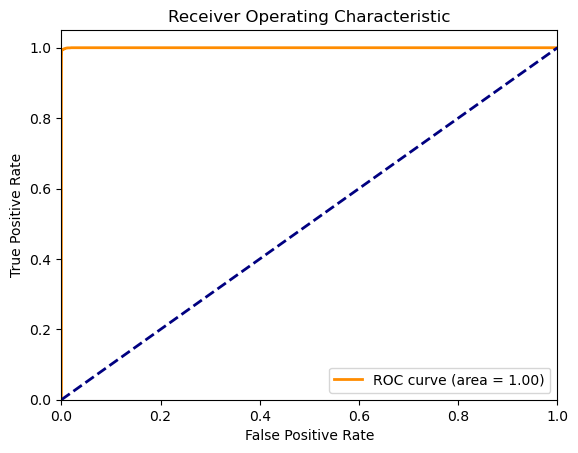

In [64]:
print('Decision Tree Result')
measure_metrics(y, y_pred_rd_smote, y_prob_rd_smote)

### Logistic Regression

In [34]:
lr.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr.predict(X_test_smote)
y_prob_lr_smote = lr.predict_proba(X_test_smote)[:, 1]

Logistic Regression Result
Accuracy: 0.8804272230501738
              precision    recall  f1-score   support

           0       0.83      0.95      0.89    110899
           1       0.95      0.81      0.87    110531

    accuracy                           0.88    221430
   macro avg       0.89      0.88      0.88    221430
weighted avg       0.89      0.88      0.88    221430

ROC AUC Score: 0.9172472359821663


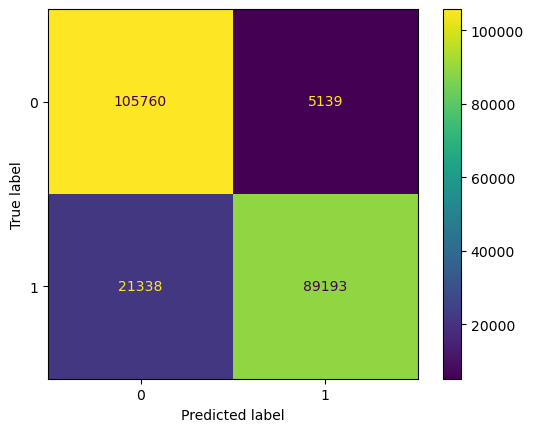

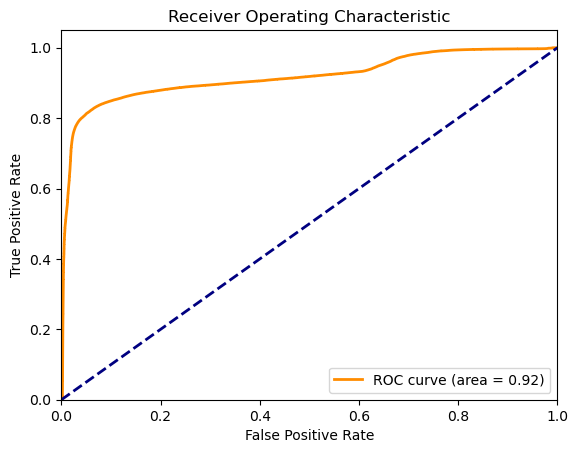

In [35]:
print('Logistic Regression Result')
measure_metrics(y_test_smote, y_pred_lr_smote, y_prob_lr_smote)

### Ensamble Model

In [43]:
from sklearn.ensemble import BaggingClassifier

In [47]:
# Create a Bagging classifier that uses the Decision Tree model
bagging_dt = BaggingClassifier(estimator=dt, random_state=42)


In [48]:
bagging_dt.fit(X_train_balanced, y_train_balanced)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

In [68]:
y_pred_bagging_dt = bagging_dt.predict(X_test)

In [69]:
y_prob_bagging_dt = bagging_dt.predict_proba(X_test)[:, 1]

Accuracy: 0.9987313755128482
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110739
           1       0.76      0.96      0.85       405

    accuracy                           1.00    111144
   macro avg       0.88      0.98      0.92    111144
weighted avg       1.00      1.00      1.00    111144

ROC AUC Score: 0.9959719768170269


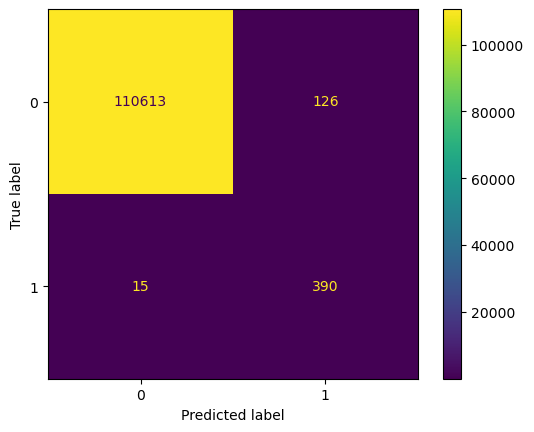

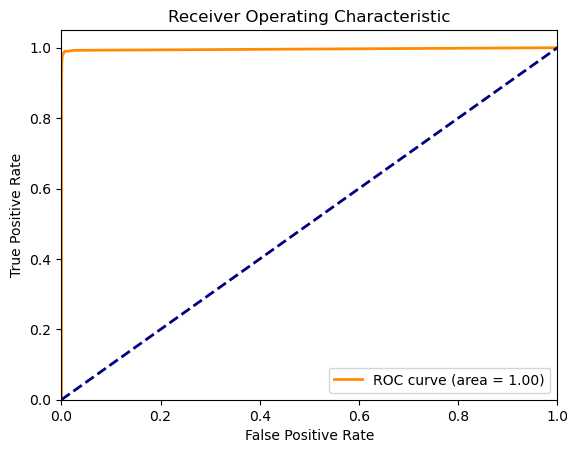

In [70]:
measure_metrics(y_test, y_pred_bagging_dt, y_prob_bagging_dt)

In [66]:
from imblearn.combine import SMOTETomek

# Instantiate SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)

# Resample the dataset
X_resampled_, y_resampled_ = smote_tomek.fit_resample(X_train, y_train)



In [67]:
rf.fit(X_resampled_, y_resampled_)


RandomForestClassifier()

In [ ]:
y_pred_rf_ = rf.predict(X_test)

In [ ]:
y_prob_rf_ = rf.predict_proba(X_test)[:, 1]